Capturing at sample interval 250000 ns
Done grabbing values.


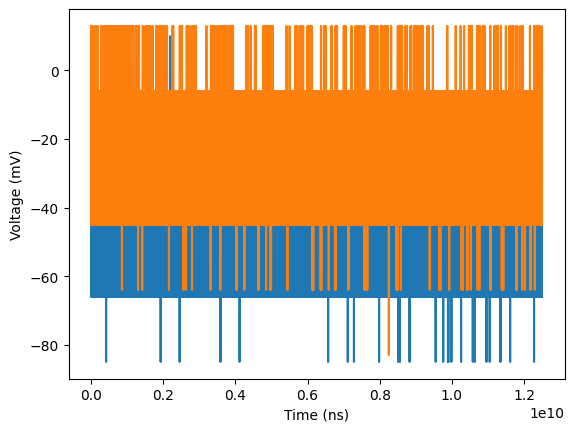

{'openunit': 0, 'setChA': 0, 'setChB': 0, 'setDataBuffersA': 0, 'setDataBuffersB': 0, 'runStreaming': 0, 'getStreamingLastestValues': 0, 'maximumValue': 0, 'stop': 0, 'close': 0}


In [7]:
#
# Copyright (C) 2018-2019 Pico Technology Ltd. See LICENSE file for terms.
#
# PS2000 Series (A API) STREAMING MODE EXAMPLE
# This example demonstrates how to call the ps4000A driver API functions in order to open a device, setup 2 channels and collects streamed data (1 buffer).
# This data is then plotted as mV against time in ns.

import ctypes
import numpy as np
from picosdk.ps4000a import ps4000a as ps
import matplotlib.pyplot as plt
from picosdk.functions import adc2mV, assert_pico_ok
import time

# Create chandle and status ready for use
chandle = ctypes.c_int16()
status = {}

# Open PicoScope 2000 Series device
# Returns handle to chandle for use in future API functions
status["openunit"] = ps.ps4000aOpenUnit(ctypes.byref(chandle), None)

try:
    assert_pico_ok(status["openunit"])
except:

    powerStatus = status["openunit"]

    if powerStatus == 286:
        status["changePowerSource"] = ps.ps4000aChangePowerSource(chandle, powerStatus)
    else:
        raise

    assert_pico_ok(status["changePowerSource"])


enabled = 1
disabled = 0
analogue_offset = 0.0

# Set up channel A
# handle = chandle
# channel = PS4000A_CHANNEL_A = 0
# enabled = 1
# coupling type = PS4000A_DC = 1
# range = PS4000A_2V = 7
# analogue offset = 0 V
channel_range = 7
status["setChA"] = ps.ps4000aSetChannel(chandle,
                                        ps.PS4000A_CHANNEL['PS4000A_CHANNEL_A'],
                                        enabled,
                                        ps.PS4000A_COUPLING['PS4000A_DC'],
                                        channel_range,
                                        analogue_offset)
assert_pico_ok(status["setChA"])

# Set up channel B
# handle = chandle
# channel = PS4000A_CHANNEL_B = 1
# enabled = 1
# coupling type = PS4000A_DC = 1
# range = PS4000A_2V = 7
# analogue offset = 0 V
status["setChB"] = ps.ps4000aSetChannel(chandle,
                                        ps.PS4000A_CHANNEL['PS4000A_CHANNEL_B'],
                                        enabled,
                                        ps.PS4000A_COUPLING['PS4000A_DC'],
                                        channel_range,
                                        analogue_offset)
assert_pico_ok(status["setChB"])

# Size of capture
sizeOfOneBuffer = 500
numBuffersToCapture = 100

totalSamples = sizeOfOneBuffer * numBuffersToCapture

# Create buffers ready for assigning pointers for data collection
bufferAMax = np.zeros(shape=sizeOfOneBuffer, dtype=np.int16)
bufferBMax = np.zeros(shape=sizeOfOneBuffer, dtype=np.int16)

memory_segment = 0

# Set data buffer location for data collection from channel A
# handle = chandle
# source = PS4000A_CHANNEL_A = 0
# pointer to buffer max = ctypes.byref(bufferAMax)
# pointer to buffer min = ctypes.byref(bufferAMin)
# buffer length = maxSamples
# segment index = 0
# ratio mode = PS4000A_RATIO_MODE_NONE = 0
status["setDataBuffersA"] = ps.ps4000aSetDataBuffers(chandle,
                                                     ps.PS4000A_CHANNEL['PS4000A_CHANNEL_A'],
                                                     bufferAMax.ctypes.data_as(ctypes.POINTER(ctypes.c_int16)),
                                                     None,
                                                     sizeOfOneBuffer,
                                                     memory_segment,
                                                     ps.PS4000A_RATIO_MODE['PS4000A_RATIO_MODE_NONE'])
assert_pico_ok(status["setDataBuffersA"])

# Set data buffer location for data collection from channel B
# handle = chandle
# source = PS4000A_CHANNEL_B = 1
# pointer to buffer max = ctypes.byref(bufferBMax)
# pointer to buffer min = ctypes.byref(bufferBMin)
# buffer length = maxSamples
# segment index = 0
# ratio mode = PS4000A_RATIO_MODE_NONE = 0
status["setDataBuffersB"] = ps.ps4000aSetDataBuffers(chandle,
                                                     ps.PS4000A_CHANNEL['PS4000A_CHANNEL_B'],
                                                     bufferBMax.ctypes.data_as(ctypes.POINTER(ctypes.c_int16)),
                                                     None,
                                                     sizeOfOneBuffer,
                                                     memory_segment,
                                                     ps.PS4000A_RATIO_MODE['PS4000A_RATIO_MODE_NONE'])
assert_pico_ok(status["setDataBuffersB"])

# Begin streaming mode:
sampleInterval = ctypes.c_int32(250)
sampleUnits = ps.PS4000A_TIME_UNITS['PS4000A_US']
# We are not triggering:
maxPreTriggerSamples = 0
autoStopOn = 1
# No downsampling:
downsampleRatio = 1
status["runStreaming"] = ps.ps4000aRunStreaming(chandle,
                                                ctypes.byref(sampleInterval),
                                                sampleUnits,
                                                maxPreTriggerSamples,
                                                totalSamples,
                                                autoStopOn,
                                                downsampleRatio,
                                                ps.PS4000A_RATIO_MODE['PS4000A_RATIO_MODE_NONE'],
                                                sizeOfOneBuffer)
assert_pico_ok(status["runStreaming"])

actualSampleInterval = sampleInterval.value
actualSampleIntervalNs = actualSampleInterval * 1000

print("Capturing at sample interval %s ns" % actualSampleIntervalNs)

# We need a big buffer, not registered with the driver, to keep our complete capture in.
bufferCompleteA = np.zeros(shape=totalSamples, dtype=np.int16)
bufferCompleteB = np.zeros(shape=totalSamples, dtype=np.int16)
nextSample = 0
autoStopOuter = False
wasCalledBack = False


def streaming_callback(handle, noOfSamples, startIndex, overflow, triggerAt, triggered, autoStop, param):
    global nextSample, autoStopOuter, wasCalledBack
    wasCalledBack = True
    destEnd = nextSample + noOfSamples
    sourceEnd = startIndex + noOfSamples
    bufferCompleteA[nextSample:destEnd] = bufferAMax[startIndex:sourceEnd]
    bufferCompleteB[nextSample:destEnd] = bufferBMax[startIndex:sourceEnd]
    nextSample += noOfSamples
    if autoStop:
        autoStopOuter = True


# Convert the python function into a C function pointer.
cFuncPtr = ps.StreamingReadyType(streaming_callback)

# Fetch data from the driver in a loop, copying it out of the registered buffers and into our complete one.
while nextSample < totalSamples and not autoStopOuter:
    wasCalledBack = False
    status["getStreamingLastestValues"] = ps.ps4000aGetStreamingLatestValues(chandle, cFuncPtr, None)
    if not wasCalledBack:
        # If we weren't called back by the driver, this means no data is ready. Sleep for a short while before trying
        # again.
        time.sleep(0.01)

print("Done grabbing values.")

# Find maximum ADC count value
# handle = chandle
# pointer to value = ctypes.byref(maxADC)
maxADC = ctypes.c_int16()
status["maximumValue"] = ps.ps4000aMaximumValue(chandle, ctypes.byref(maxADC))
assert_pico_ok(status["maximumValue"])

# Convert ADC counts data to mV
adc2mVChAMax = adc2mV(bufferCompleteA, channel_range, maxADC)
adc2mVChBMax = adc2mV(bufferCompleteB, channel_range, maxADC)

# Create time data
time = np.linspace(0, (totalSamples - 1) * actualSampleIntervalNs, totalSamples)

# Plot data from channel A and B
plt.plot(time, bufferCompleteA[:])
plt.plot(time, bufferCompleteB[:])
plt.xlabel('Time (ns)')
plt.ylabel('Voltage (mV)')
plt.show()

# Stop the scope
# handle = chandle
status["stop"] = ps.ps4000aStop(chandle)
assert_pico_ok(status["stop"])

# Disconnect the scope
# handle = chandle
status["close"] = ps.ps4000aCloseUnit(chandle)
assert_pico_ok(status["close"])

# Display status returns
print(status)


In [5]:
import numpy as np
import ctypes
import plotly.express as px
import time

import picosdk.ps4000a as ps
from picosdk.functions import adc2mV, assert_pico_ok

In [6]:
# Pico status and handle
status = {}
chandle = ctypes.c_int16()

# initialize
status["openunit"] = ps.ps4000aOpenUnit(ctypes.byref(chandle), None)

try:
    assert_pico_ok(status["openunit"])
except:

    powerStatus = status["openunit"]

    if powerStatus == 286:
        status["changePowerSource"] = ps.ps4000aChangePowerSource(chandle, powerStatus)
    else:
        raise

    assert_pico_ok(status["changePowerSource"])

AttributeError: module 'picosdk.ps4000a' has no attribute 'ps4000aOpenUnit'

In [2]:
SAMPLES = 5e6 

# init scope
scope = psdk.ps6000a()
scope.open_unit()

PicoSDKException: Pico Not Found: No Pico Technology device could be found.